<img src="../assets/header.gif" style="width:100%">
<hr style="color:#808080;">
<p align="center"><b>S H A G G Y &mdash; C A E   v s   G A E</b></p>
<hr style="color:#808080;">

A side-by-side demonstration of `shaggy`'s two auto-encoder architectures —
`ConvAE` (`shaggy.models.cae`) and `GraphAE` (`shaggy.models.gae`, inspired by the
Njord paper) — trained simultaneously on the same real Black Sea state (temperature
and oxygen at 4 depths each, on a `128 x 256` grid, land cells masked out).

Steps: load the data and the mesh built in `demo-graphs.ipynb` &rarr; build a
ConvAE and a GraphAE with matching hyperparameters &rarr; train both at once, with a
live dual-line loss plot &rarr; compare reconstruction quality: ConvAE vs GraphAE vs
ground truth.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from IPython.display import clear_output
from pathlib import Path

from shaggy.loss import AELoss
from shaggy.models.cae import create_ConvAE
from shaggy.models.gae import create_GraphAE
from shaggy.models.tools import build_mesh
from shaggy.optimizers import SOAP, HybridMA, safe_gradient_step

# This machine exposes a lot of CPU cores (shared HPC node); torch's default of
# spawning that many threads for tiny per-node tensor ops is pure overhead here
# and makes the graph ops ~100x slower than they need to be. A handful is plenty.
torch.set_num_threads(4)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


<hr style="color:#808080;">
<p align="center"><b>D A T A</b></p>
<hr style="color:#808080;">


In [ ]:
x = torch.load("data/x.pt")        # (N, C, Y, X), NaN on land
mask = torch.load("data/mask.pt")  # (C, Y, X), 1 = sea, 0 = land, one mask per channel

N, C, Y, X = x.shape
print(f"x    : {tuple(x.shape)}  ({N} samples, {C} channels, {Y}x{X} grid)")
print(f"mask : {tuple(mask.shape)}")

# Land cells are filled with 0 (never used directly: AELoss below weights them out
# of the loss with `mask`, so their exact value never matters).
x_filled = torch.nan_to_num(x, nan=0.0).to(device)
weights = mask.unsqueeze(0).to(device)  # (1, C, Y, X), broadcasts over the batch


In [ ]:
def show_field(ax, field, chan_mask, title, vmin=None, vmax=None, cmap="RdBu_r"):
    r'''Displays one (Y, X) field, land cells left blank, oriented for the Black Sea.'''
    field = torch.flipud(field).detach().cpu().numpy()
    m = torch.flipud(chan_mask).cpu().numpy()

    cmap = plt.get_cmap(cmap).copy()
    cmap.set_bad("lightgray")
    field = np.ma.masked_where(m < 0.5, field)

    im = ax.imshow(field, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
    return im


# A quick look at the raw data: temperature (channels 0-3) and oxygen (4-7), from
# shallowest to deepest, for the first sample.
fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for c in range(C):
    ax = axes[c // 4, c % 4]
    vmin, vmax = np.nanpercentile(x[0, c].cpu().numpy(), [5, 95])
    im = show_field(ax, x_filled[0, c], mask[c], f"channel {c}", vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle("Sample 0, all channels (temperature: 0-3, oxygen: 4-7, shallow to deep)")
plt.tight_layout()
plt.show()


<hr style="color:#808080;">
<p align="center"><b>M E S H</b></p>
<hr style="color:#808080;">

`GraphAE` needs a mesh (see `demo-graphs.ipynb`, which builds and saves one over
this exact domain). Loaded here rather than rebuilt — meshes don't depend on model
weights, so there's no reason to pay for K-means again.


In [30]:
NUM_LEVELS, REDUCTION, K, ITERATIONS, SEED = 5, 2, 32, 8, 0
MESH_PATH = Path(f"data/mesh_L{Y}x{X}_r{REDUCTION}_k{K}_lvl{NUM_LEVELS}_seed{SEED}.pt")

if MESH_PATH.exists():
    mesh = torch.load(MESH_PATH, weights_only=False)
    print(f"Loaded cached mesh from {MESH_PATH} (built in demo-graphs.ipynb)")
else:
    domain_mask = mask.bool().any(dim=0)
    mesh = build_mesh(
        resolution=(Y, X), num_levels=NUM_LEVELS, reduction=REDUCTION, k=K, iterations=ITERATIONS, mask=domain_mask, seed=SEED,
    )
    torch.save(mesh, MESH_PATH)
    print(f"No cached mesh found: built and saved a new one to {MESH_PATH}")

print(f"Mesh levels: {[p.shape[0] for p in mesh.pos]} nodes")


Loaded cached mesh from data/mesh_L128x256_r2_k32_lvl5_seed0.pt (built in demo-graphs.ipynb)
Mesh levels: [19172, 9586, 4793, 2396, 1198, 599] nodes


<hr style="color:#808080;">
<p align="center"><b>M O D E L S</b></p>
<hr style="color:#808080;">

Both models share the same values wherever a hyperparameter name applies to both
architectures (`hid_channels`, `hid_blocks`, `lat_channels`, `saturation`,
`saturation_bound`); `ConvAE` additionally takes `spatial` (grid dimensionality),
`GraphAE` the `mesh` built above.


In [31]:
config = dict(
    hid_channels=[8, 16, 32, 64, 128],
    hid_blocks=[3, 3, 3, 3, 3],
    lat_channels=16,
    saturation="softclip2",
    saturation_bound=5.0,
)

cae = create_ConvAE(in_channels=C, out_channels=C, spatial=2, **config).to(device)
gae = create_GraphAE(in_channels=C, out_channels=C, mesh=mesh, **config).to(device)

for name, model in [("ConvAE", cae), ("GraphAE", gae)]:
    n_params = sum(p.numel() for p in model.parameters())
    latent, factor = model.compression_info((C, Y, X))
    print(f"{name:<8}: {n_params:>9,} parameters   latent {str(latent):<14}  compression x{factor}")


ConvAE  : 3,182,224 parameters   latent (16, 8, 16)     compression x128
GraphAE :   867,712 parameters   latent (599, 16)       compression x27


<hr style="color:#808080;">
<p align="center"><b>T R A I N I N G</b></p>
<hr style="color:#808080;">

Only 16 samples are available, so this is a reconstruction/memorization check on
real data rather than a generalization benchmark — both models see and are
evaluated on the same fields. Trained together: one step of ConvAE, one step of
GraphAE, same data, separate optimizers, same number of steps, so the two loss
curves are directly comparable throughout. GraphAE gets a higher learning rate
(see below): its updates propagate through a sparser message-passing hierarchy
rather than dense convolutions, so it converges more slowly step-for-step.


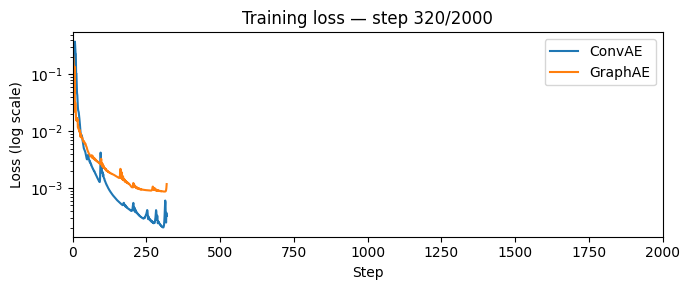

KeyboardInterrupt: 

In [32]:
STEPS = 2000
LR_CAE, LR_GAE = 5e-3, 5e-3  # GraphAE's sparser message-passing updates converge
                              # more slowly, so it gets a higher learning rate to
                              # reach a comparable quality within the same step budget

loss_fn = AELoss(weights=weights).to(device)
opt_cae = SOAP(cae.parameters(), lr=LR_CAE)
opt_gae = SOAP(gae.parameters(), lr=LR_GAE)

losses_cae, losses_gae = [], []

for step in range(1, STEPS + 1):
    _, x_hat_cae = cae(x_filled)
    loss_cae = loss_fn(x_hat_cae, x_filled)
    loss_cae.backward()
    safe_gradient_step(opt_cae)

    _, x_hat_gae = gae(x_filled)
    loss_gae = loss_fn(x_hat_gae, x_filled)
    loss_gae.backward()
    safe_gradient_step(opt_gae)

    losses_cae.append(loss_cae.item())
    losses_gae.append(loss_gae.item())

    if step % 10 == 0 or step == STEPS:
        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(7, 3))
        ax.plot(losses_cae, label="ConvAE", linewidth=1.5)
        ax.plot(losses_gae, label="GraphAE", linewidth=1.5)
        ax.set_yscale("log")
        ax.set_xlim(0, STEPS)
        ax.set_xlabel("Step")
        ax.set_ylabel("Loss (log scale)")
        ax.set_title(f"Training loss — step {step}/{STEPS}")
        ax.legend()
        plt.tight_layout()
        plt.show()


<hr style="color:#808080;">
<p align="center"><b>E V A L U A T I O N</b></p>
<hr style="color:#808080;">

Masked RMSE (land cells excluded) for each model against ground truth, plus a
naive mean-baseline (predicting the per-pixel average over all samples) for
reference.


In [34]:
def rmse_per_sample(pred, target, weights):
    r'''Masked RMSE per sample, ignoring land cells.'''
    error2 = (pred - target) ** 2 * weights
    return torch.sqrt(error2.sum(dim=(1, 2, 3)) / weights.sum(dim=(1, 2, 3)).clamp(min=1))


cae.eval()
gae.eval()

with torch.no_grad():
    _, recon_cae = cae(x_filled)
    _, recon_gae = gae(x_filled)

rmse_cae = rmse_per_sample(recon_cae, x_filled, weights)
rmse_gae = rmse_per_sample(recon_gae, x_filled, weights)

baseline = x_filled.mean(dim=0, keepdim=True).expand_as(x_filled)
rmse_baseline = rmse_per_sample(baseline, x_filled, weights)

print(f"{'sample':<8}{'ConvAE':>10}{'GraphAE':>10}{'mean-baseline':>16}")
for i in range(N):
    print(f"{i:<8}{rmse_cae[i].item():>10.4f}{rmse_gae[i].item():>10.4f}{rmse_baseline[i].item():>16.4f}")
print(f"{'mean':<8}{rmse_cae.mean().item():>10.4f}{rmse_gae.mean().item():>10.4f}{rmse_baseline.mean().item():>16.4f}")


sample      ConvAE   GraphAE   mean-baseline
0           0.0218    0.0448          0.0565
1           0.0221    0.0472          0.0548
2           0.0210    0.0461          0.0518
3           0.0206    0.0454          0.0487
4           0.0204    0.0451          0.0477
5           0.0209    0.0461          0.0496
6           0.0203    0.0452          0.0537
7           0.0206    0.0469          0.0550
8           0.0193    0.0444          0.0479
9           0.0211    0.0475          0.0481
10          0.0203    0.0469          0.0490
11          0.0204    0.0462          0.0550
12          0.0203    0.0450          0.0603
13          0.0218    0.0480          0.0691
14          0.0219    0.0482          0.0757
15          0.0217    0.0490          0.0858
mean        0.0209    0.0464          0.0568


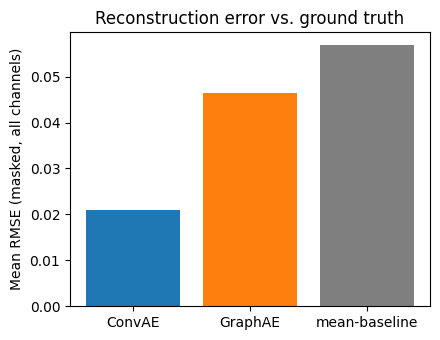

In [35]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))
names = ["ConvAE", "GraphAE", "mean-baseline"]
means = [rmse_cae.mean().item(), rmse_gae.mean().item(), rmse_baseline.mean().item()]
ax.bar(names, means, color=["C0", "C1", "C7"])
ax.set_ylabel("Mean RMSE (masked, all channels)")
ax.set_title("Reconstruction error vs. ground truth")
plt.tight_layout()
plt.show()


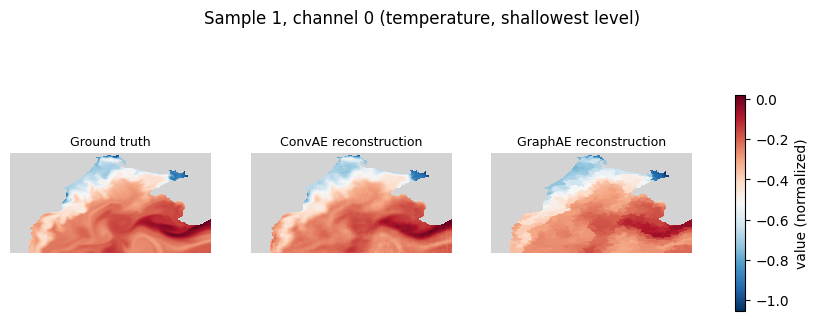

In [36]:
SAMPLE, CHANNEL = 1 , 0

truth = x_filled[SAMPLE, CHANNEL]
pred_cae = recon_cae[SAMPLE, CHANNEL]
pred_gae = recon_gae[SAMPLE, CHANNEL]
chan_mask = mask[CHANNEL]

sea = chan_mask.bool()
vmin, vmax = truth[sea].min().item(), truth[sea].max().item()

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
im = show_field(axes[0], truth, chan_mask, "Ground truth", vmin, vmax)
show_field(axes[1], pred_cae, chan_mask, "ConvAE reconstruction", vmin, vmax)
show_field(axes[2], pred_gae, chan_mask, "GraphAE reconstruction", vmin, vmax)
fig.colorbar(im, ax=axes, shrink=0.7, label="value (normalized)")
plt.suptitle(f"Sample {SAMPLE}, channel {CHANNEL} (temperature, shallowest level)")
plt.show()


The RMSE table/bar chart above give the exact numbers for this run (both models
are randomly initialized, so re-running the notebook will shift them slightly);
both should clearly beat the mean-baseline, which has no notion of *which* sample
it's reconstructing. `ConvAE` and `GraphAE` compress the same state through very
different mechanisms — striding convolutions over the full masked grid vs. message
passing over a hierarchy of masked meshes — but are trained and evaluated here on
identical terms, so the numbers above are directly comparable.
